In [137]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from matplotlib.backends.backend_pdf import PdfPages
from sklearn.preprocessing import LabelEncoder

# Load the dataset
df = pd.read_csv(r'D:\\fraud-detection-project\\data\\raw_transactions.csv')

# Create a PDF file to save visualizations
pdf_filename = r'D:\\fraud-detection-project\\EDA_report.pdf'

# Store all figure sizes to determine the largest one
figure_sizes = [
    (8, 4),  # Dataset Overview
    (10, 6),  # Transaction Amount Distribution
    (8, 6),  # Fraud vs Non-Fraud Distribution
    (12, 6),  # Category-Wise Fraud Analysis
    (10, 8),  # Transaction Network Graph
    (12, 6),  # Time-Based Transaction Analysis
]

# Find the maximum figure size
max_width, max_height = max(figure_sizes, key=lambda x: x[0] * x[1])

# Use the largest figure size across all pages
pdf_pages = PdfPages(pdf_filename)
plt.rcParams["figure.figsize"] = (max_width, max_height)

# Function to save text analysis to PDF
def save_text_page(title, content):
    plt.figure(figsize=(max_width, max_height))
    plt.text(0.1, 0.9, title, fontsize=20, fontweight='bold')
    plt.text(0.1, 0.7, content, fontsize=12, verticalalignment='top', wrap=True)
    plt.axis('off')
    pdf_pages.savefig()
    plt.close()

# Dataset Overview
save_text_page("Exploratory Data Analysis Report",
               f"Dataset Overview:\n\nNumber of Rows: {df.shape[0]}\nNumber of Columns: {df.shape[1]}")

print("Dataset Info:")
print(df.info())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Sender            1000 non-null   int64 
 1   Receiver          1000 non-null   int64 
 2   Amount            1000 non-null   int64 
 3   Category          1000 non-null   object
 4   Transaction_Date  1000 non-null   object
 5   Fraudulent        1000 non-null   int64 
dtypes: int64(4), object(2)
memory usage: 47.0+ KB
None


Data Analysis

In [138]:
# Check for missing values
missing_values = df.isnull().sum()
save_text_page("Missing Values Analysis", str(missing_values))

print("Missing Values:\n", missing_values)

# Summary statistics of numeric columns
df_summary = df.describe()

Missing Values:
 Sender              0
Receiver            0
Amount              0
Category            0
Transaction_Date    0
Fraudulent          0
dtype: int64


Visualizing Transaction Amount Distribution

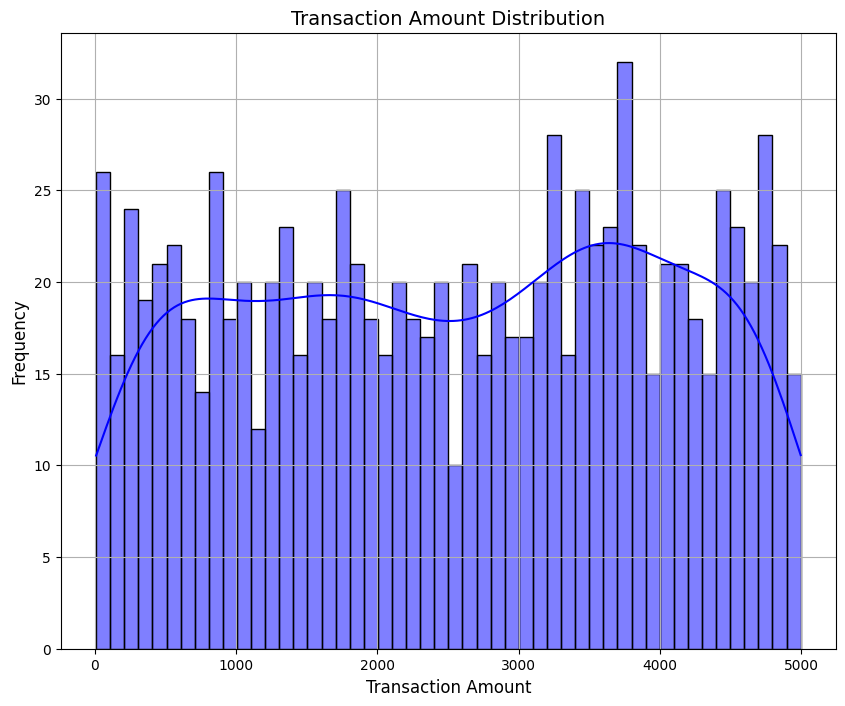

In [139]:
plt.figure()
sns.histplot(df['Amount'], bins=50, kde=True, color='blue')
plt.title('Transaction Amount Distribution')
plt.xlabel('Transaction Amount')
plt.ylabel('Frequency')
plt.grid()
pdf_pages.savefig()  # Save the plot to PDF
plt.show()
plt.close()

Fraud vs Non-Fraud Distribution

C:\Users\phani\AppData\Local\Temp\ipykernel_14708\1356633624.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Fraudulent', data=df, palette='coolwarm')


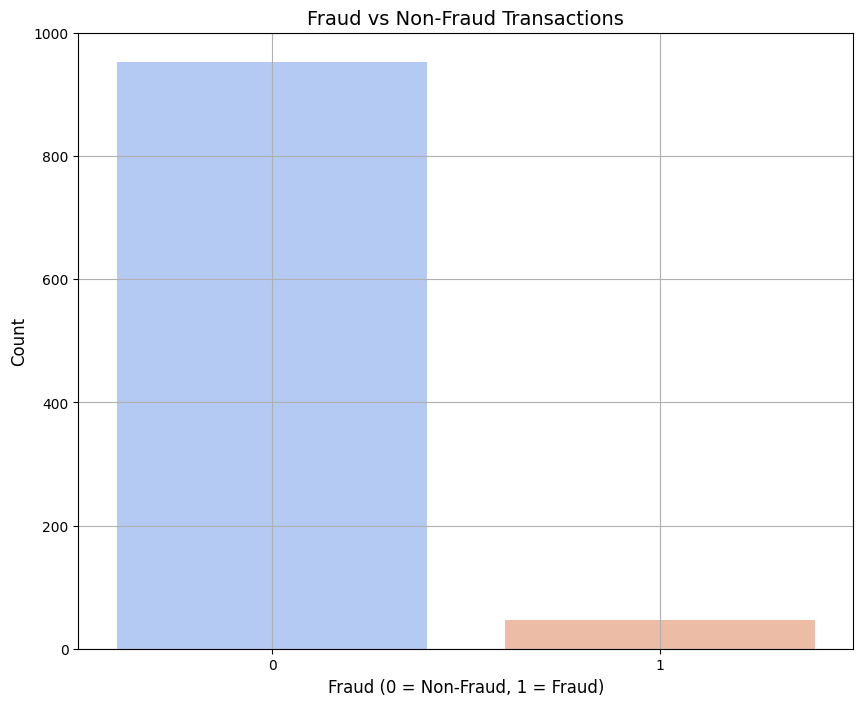

In [140]:
plt.figure()
sns.countplot(x='Fraudulent', data=df, palette='coolwarm')
plt.title('Fraud vs Non-Fraud Transactions')
plt.xlabel('Fraud (0 = Non-Fraud, 1 = Fraud)')
plt.ylabel('Count')
plt.grid()
pdf_pages.savefig()
plt.show()
plt.close()

# Fraud Percentage Calculation
fraud_percentage = df['Fraudulent'].value_counts(normalize=True) * 100
save_text_page("Fraudulent vs Non-Fraudulent Transactions",
               f"Fraudulent transactions make up {fraud_percentage[1]:.2f}% of total transactions.")

Relationship Between Transaction Amount and Fraud

C:\Users\phani\AppData\Local\Temp\ipykernel_14708\4094869227.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Fraudulent', y='Amount', data=df, palette='coolwarm')


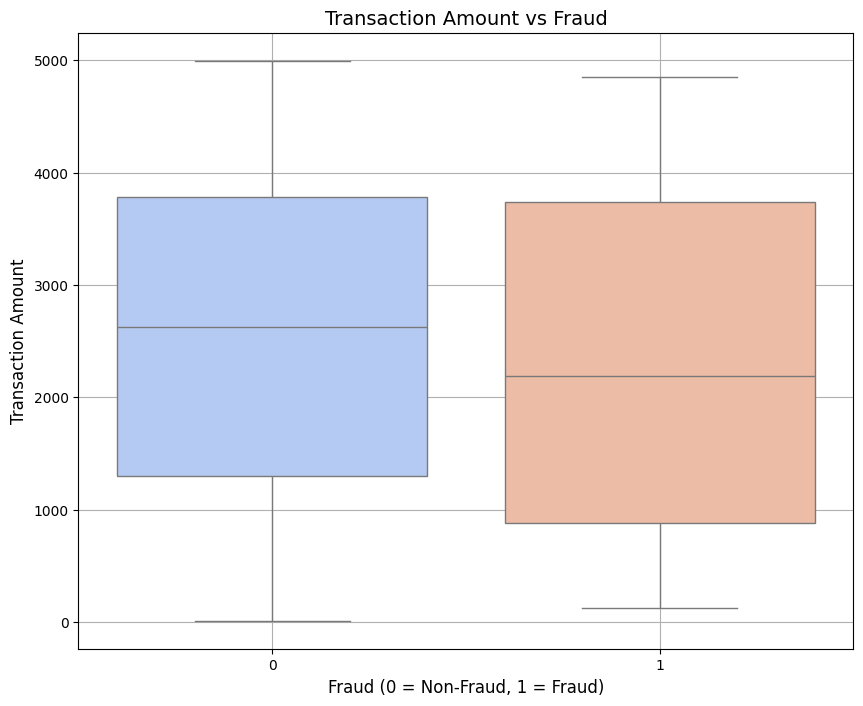

In [141]:
plt.figure()
sns.boxplot(x='Fraudulent', y='Amount', data=df, palette='coolwarm')
plt.title('Transaction Amount vs Fraud')
plt.xlabel('Fraud (0 = Non-Fraud, 1 = Fraud)')
plt.ylabel('Transaction Amount')
plt.grid()
pdf_pages.savefig()
plt.show()
plt.close()

Category-Wise Fraud Analysis

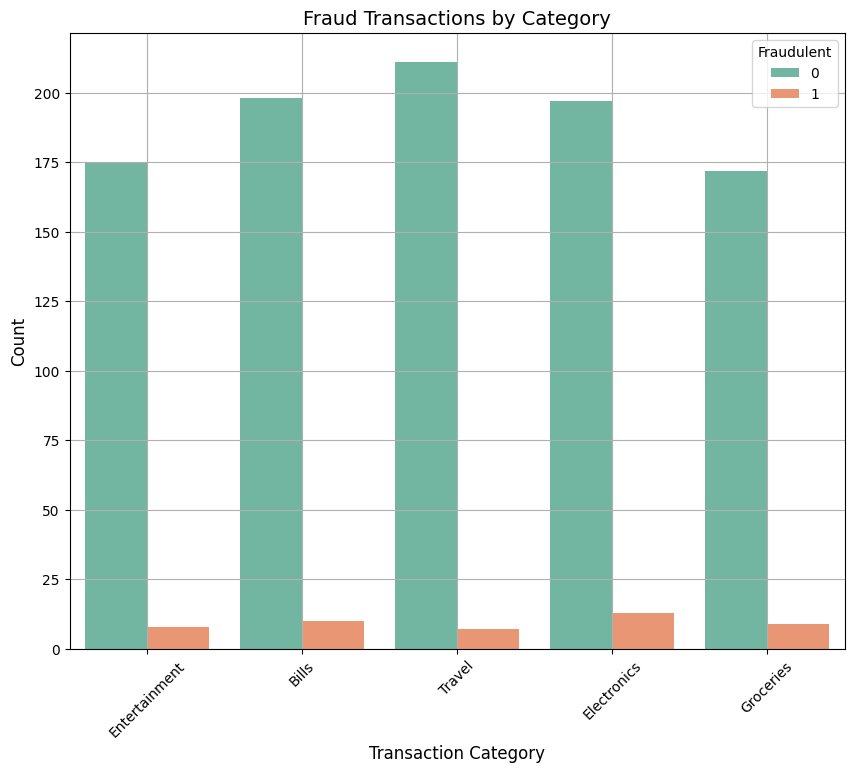

In [142]:
plt.figure()
sns.countplot(x='Category', hue='Fraudulent', data=df, palette='Set2')
plt.title('Fraud Transactions by Category')
plt.xlabel('Transaction Category')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.grid()
pdf_pages.savefig()
plt.show()
plt.close()

Building a Graph from Transactions

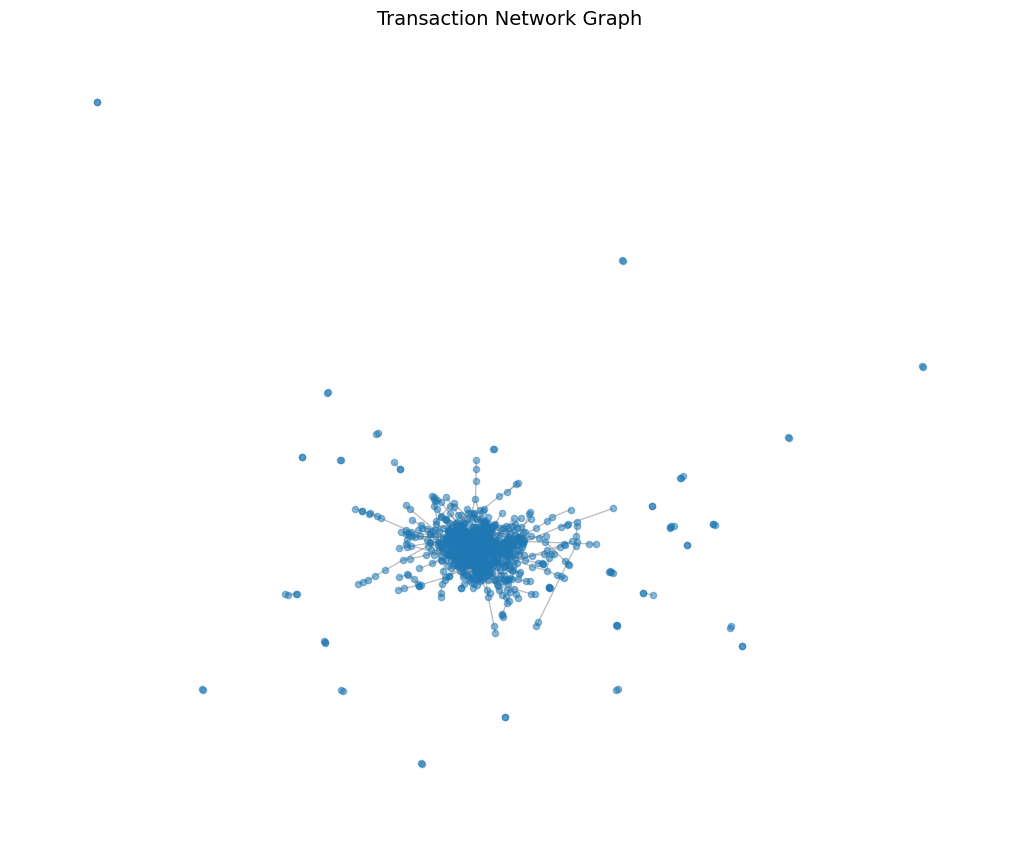

Number of nodes: 861
Number of edges: 1000


In [143]:
# Create a graph using NetworkX
G = nx.Graph()

# Add edges (sender-receiver relationships)
for _, row in df.iterrows():
    G.add_edge(row['Sender'], row['Receiver'], weight=row['Amount'])

plt.figure()
nx.draw(G, node_size=20, edge_color='gray', alpha=0.5)
plt.title('Transaction Network Graph')
pdf_pages.savefig()
plt.show()
plt.close()

# Analysis Explanation - Network Graph
plt.figure()
plt.text(0.1, 0.8, "Transaction Network Analysis", fontsize=16, fontweight='bold')
plt.text(0.1, 0.6, "Visualizing relationships between senders and receivers.", fontsize=12)
plt.axis('off')
pdf_pages.savefig()
plt.close()

print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())

Correlation Heatmap

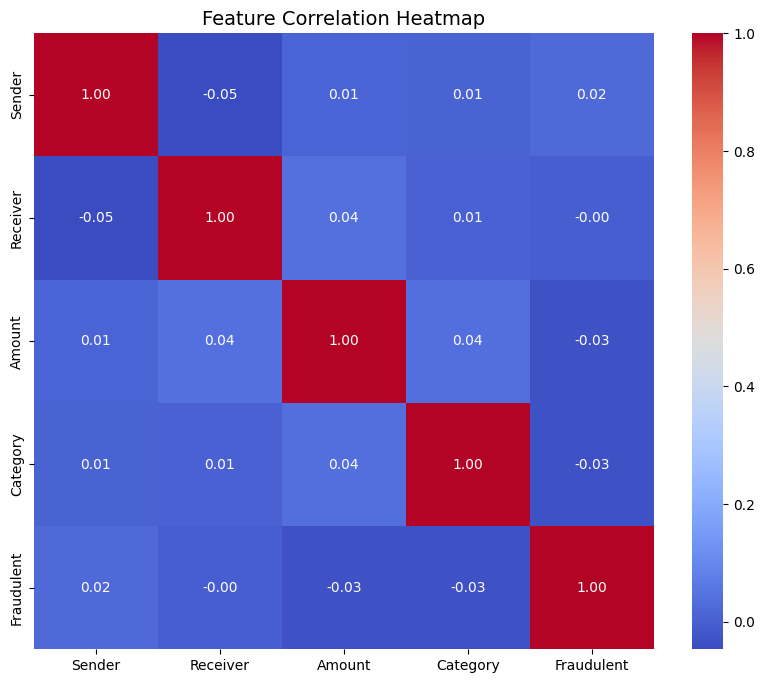

In [144]:
# Convert Transaction_Date to datetime format
df['Transaction_Date'] = pd.to_datetime(df['Transaction_Date'], errors='coerce')

# Drop non-numeric columns before correlation calculation
df_numeric = df.drop(columns=['Transaction_Date'])

# Encode categorical columns
label_encoder = LabelEncoder()
df_numeric['Category'] = label_encoder.fit_transform(df_numeric['Category'])

# Generate the correlation heatmap
plt.figure()
sns.heatmap(df_numeric.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
pdf_pages.savefig()
plt.show()
plt.close()

Analyzing Transaction Frequency by Users

C:\Users\phani\AppData\Local\Temp\ipykernel_14708\3946140246.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_senders.index, y=top_senders.values, palette='viridis')
C:\Users\phani\AppData\Local\Temp\ipykernel_14708\3946140246.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_receivers.index, y=top_receivers.values, palette='magma')


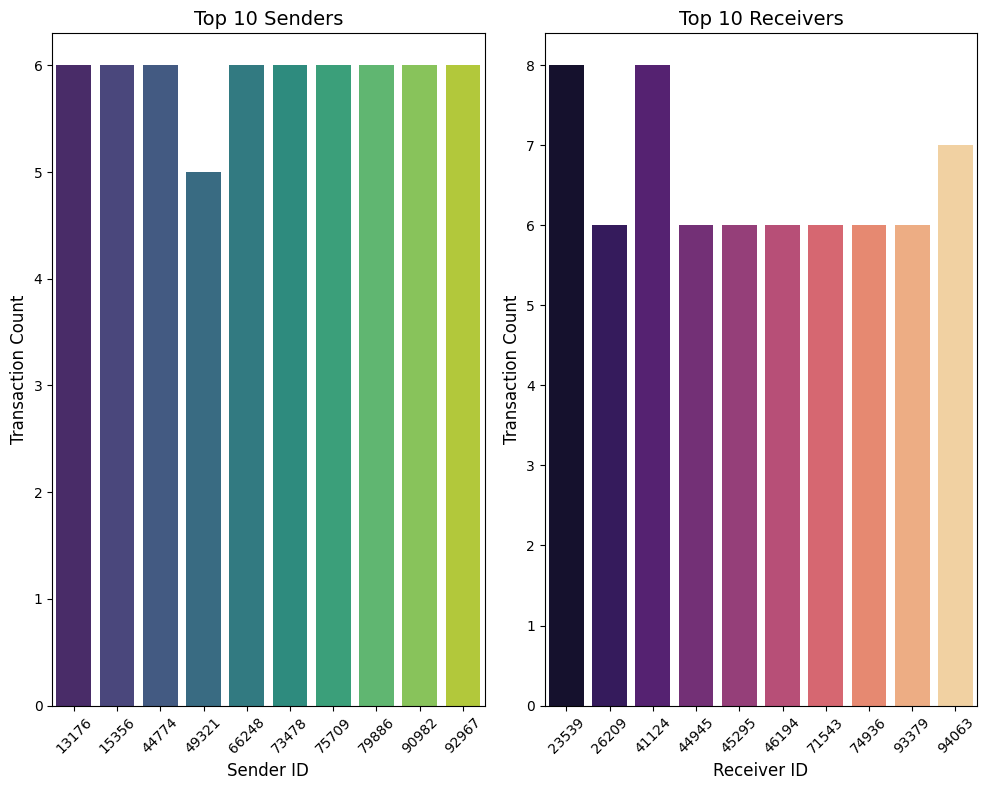

In [145]:
top_senders = df['Sender'].value_counts().head(10)
top_receivers = df['Receiver'].value_counts().head(10)

plt.figure()
plt.subplot(1, 2, 1)
sns.barplot(x=top_senders.index, y=top_senders.values, palette='viridis')
plt.title('Top 10 Senders')
plt.xlabel('Sender ID')
plt.ylabel('Transaction Count')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
sns.barplot(x=top_receivers.index, y=top_receivers.values, palette='magma')
plt.title('Top 10 Receivers')
plt.xlabel('Receiver ID')
plt.ylabel('Transaction Count')
plt.xticks(rotation=45)

plt.tight_layout()
pdf_pages.savefig()
plt.show()
plt.close()

Time-Based Transaction Analysis

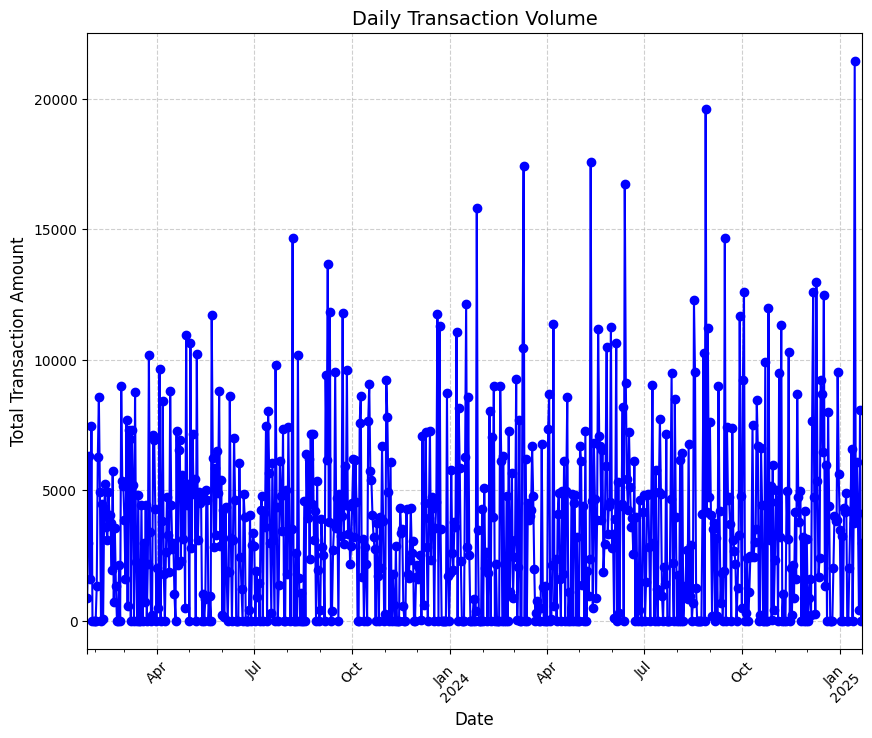

In [146]:
df['Transaction_Date'] = pd.to_datetime(df['Transaction_Date'], errors='coerce')
df = df.dropna(subset=['Transaction_Date'])
df.set_index('Transaction_Date', inplace=True)
df = df.sort_index()

plt.figure()
df['Amount'].resample('D').sum().plot(marker='o', color='blue', linewidth=1.5)
plt.title('Daily Transaction Volume')
plt.xlabel('Date')
plt.ylabel('Total Transaction Amount')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45)
pdf_pages.savefig()
plt.show()
plt.close()

Save plot results to PDF report file

In [147]:
# Save and close the PDF file
pdf_pages.close()
print(f"EDA Report saved successfully as {pdf_filename}")

EDA Report saved successfully as D:\\fraud-detection-project\\EDA_report.pdf
